In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 


In [4]:
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/linear regression/data sets/DailyDelhiClimateTest.csv")
df = pd.DataFrame(data)

In [5]:
df.shape

(114, 5)

In [6]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017/1/1,15.913043,85.869565,2.743478,59.000000
1,2017/1/2,18.500000,77.222222,2.894444,1018.277778
2,2017/1/3,17.111111,81.888889,4.016667,1018.333333
3,2017/1/4,18.700000,70.050000,4.545000,1015.700000
4,2017/1/5,18.388889,74.944444,3.300000,1014.333333


In [15]:
df.corr(numeric_only = True)

,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.857726,0.217743,0.030682
humidity,-0.857726,1.000000,-0.340507,-0.097869
wind_speed,0.217743,-0.340507,1.000000,0.130352
meanpressure,0.030682,-0.097869,0.130352,1.000000


In [8]:
print(df.iloc[0,1])

15.91304348


In [9]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [10]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017/1/1,15.913043,85.869565,2.743478,59.000000
1,2017/1/2,18.500000,77.222222,2.894444,1018.277778
2,2017/1/3,17.111111,81.888889,4.016667,1018.333333
3,2017/1/4,18.700000,70.050000,4.545000,1015.700000
4,2017/1/5,18.388889,74.944444,3.300000,1014.333333


In [8]:
df.corr(numeric_only = True)

,meantemp,humidity,wind_speed,meanpressure
meantemp,1.000000,-0.857726,0.217743,0.030682
humidity,-0.857726,1.000000,-0.340507,-0.097869
wind_speed,0.217743,-0.340507,1.000000,0.130352
meanpressure,0.030682,-0.097869,0.130352,1.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


-0.8577257221103037 -1.1101061590436312e-16
-2.5715409388893273 112.09443318998457
7231
mean square error: 0.26198725164559045 std of y 1.0
root mean square error: 0.511846902545664
R-squared: 0.7356942771009087


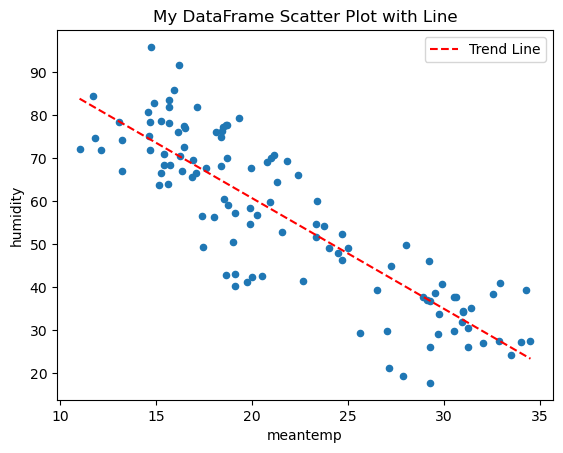

In [14]:
xorig = df.iloc[:,1]
yorig = df.iloc[:,2]

x = (xorig - xorig.mean()) / xorig.std()
y = (yorig - yorig.mean()) / yorig.std()
n= len(x)
w = 0 
b= 0 
tol = 1e-6
xdata = x
ydata = y
alpha = 0.001

max_iter = 20000

for i in range(max_iter):
    ypred = w*xdata+b
    
    
    error = ydata - ypred
    
    jw = (-2/n)* np.sum(xdata * error)
    jb = (-2/n) * np.sum(error)
    
    w = w - alpha * jw 
    b = b - alpha * jb
    if abs(jw)<tol and abs(jb)<tol:
       break

worig = w * (yorig.std()/xorig.std())
borig = yorig.mean() - (worig * xorig.mean())

print(w,b)
print(worig , borig)
print(i+1)


# goodness of fit using r2
mse = np.mean(error**2)
rmse = np.sqrt(mse)


ymean = np.mean(y)
ss_res = np.sum(error**2)
ss_tot = np.sum((y-ymean)**2)
r2 = 1- (ss_res/ss_tot)

print(f"mean square error: {mse}", f"std of y {y.std()}")
print(f"root mean square error: {rmse}")
print(f"R-squared: {r2}")




ax = df.plot.scatter(x = 'meantemp' , y ='humidity')


x_vals = np.linspace(xorig.min(), xorig.max(), 100)
yvalues = (x_vals * worig) + borig


ax.plot(x_vals, yvalues, color='red', linestyle='--', label='Trend Line')

plt.title('My DataFrame Scatter Plot with Line')
plt.legend()
plt.show()


# one of the first attempt that did not work! Because of
poor iteration method and poor sumation method; best iteration method is for loop but i used while loop 
poor sumation method to sum i used for loop but the best way was to first store them in list then do calulation between between the lists then sum them using np.sum() 
poor data handling first i tried to learn values that were not normalized. 
used different updating system for the slop and intercept. the correct method was to update them at the same time.






x = df.iloc[:,1]
y = df.iloc[:,2]

x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()
a = 0.0001
m1 = 0
m2 = 0
f = 0 
v,z = df.shape
n = v 
k=1
k1 = 1

iter = 0
while (k > 0.0001 or k1 > 0.0001) and iter < 1000:
    
    b = 0
    b1 = 0 
    for f in range (n):
        xi = x
        yi = y
        l = (yi - ((m2*xi) +  m1))
        c = xi * l
        b1 += l
        b += c
    d = m2 + (a * (2/n) *b)
    d1 = m1 +(a * (2/n) *b1)
    k  = abs((-2/n) *b)
    k1 = abs((-2/n) *b1)
    m2 = d
    m1 = d1
    iter += 1

    
print(m1, m2)
print(k , k1)

m2_orig = m2 * (y.std() / x.std())
m1_orig = y.mean() - m2_orig * x.mean()
            

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load your data ---
# Example: your df has columns 'meantemp' and 'humidity'
# df = pd.read_csv("your_file.csv")  # replace with your file

# For demonstration, let's assume df is already defined
x = df['meantemp'].values
y = df['humidity'].values

# --- 2. Normalize data for gradient descent ---
x_norm = (x - x.mean()) / x.std()
y_norm = (y - y.mean()) / y.std()

# --- 3. Initialize parameters ---
m1 = 0  # intercept
m2 = 0  # slope
alpha = 0.01  # learning rate
n = len(x_norm)
tol = 1e-5  # convergence tolerance
max_iter = 10000

# --- 4. Gradient descent loop ---
for i in range(max_iter):
    # Predictions

    
    y_pred = m2 * x_norm + m1
    error = y_norm - y_pred

    # Gradients
    grad_m2 = (-2/n) * np.sum(x_norm * error)
    grad_m1 = (-2/n) * np.sum(error)

    # Update parameters
    m2 = m2 - alpha * grad_m2
    m1 = m1 - alpha * grad_m1

    # Check convergence
    if abs(grad_m2) < tol and abs(grad_m1) < tol:
        break

print(f"Slope (m2): {m2}")
print(f"Intercept (m1): {m1}")
print(f"Iterations: {i+1}")
print (y_pred)

# --- 5. Plot original data and regression line ---
plt.scatter(x, y, alpha=0.5, label='Data')

# Regression line (convert back to original scale)
# y = m2 * ((x - mean_x)/std_x) + m1   => scale back to original
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = m2 * ((x_vals - x.mean())/x.std()) + m1
# Scale y back to original scale
"""y_vals = y_vals * y.std() + y.mean()
m1_orig = m1 * y.std() + y.mean() - m2 * y.std() * x.mean() / x.std()
m2_orig = m2 * y.std() / x.std()"""
y_vals = m2_orig * x_vals + m1_orig

plt.plot(x_vals, y_vals, color='red', linestyle='--', label='Regression Line')
plt.xlabel('Mean Temperature')
plt.ylabel('Humidity')
plt.title('Linear Regression: Humidity vs Mean Temperature')
plt.legend()
plt.show()
print(m1_orig, m2_orig)



In [ ]:
print(ypred)

In [ ]:
df.corr(numeric_only = True)